In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Define the function
def RKF(t1, theta_0, v_0, h0, atol, rtol):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = [0]
    # n is the number of timesteps in t
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = []
    #same for velocities
    v = []
    
    e = []
    
    #declare array to store acceleration at each point, I am considering acceleration 
    #because I want to see how the rate of change of position varies with rate of change of velocity, 
    # I have a hunch that the solution is breaking down because the velocity and position are at their 
    # max rates of change at opposite times, hence they are battling for control of the step size. 
    acceleration = []
    
    #Set the initial value of x and v
    
    g = 9.8
    l = 1
    
    a21 = 1/5
    a31 = 3/40
    a32 = 9/40
    a41 = 44/45
    a42 = -56/15
    a43 = 32/9
    a51 = 19372/6561
    a52 = -25360/2187
    a53 = 64448/6561
    a54 = -212/729
    a61 = 9017/3168
    a62 = -355/33
    a63 = 46732/5247
    a64 = 49/176
    a65 = -5103/18656
    
    b1 = 35/384
    b2 = 0
    b3 = 500/1113
    b4 = 125/192
    b5 = -2187/6784
    b6 = 11/84
    
    bx1 = 5179/57600
    bx2 = 0
    bx3 = 7571/16695
    bx4 = 393/640
    bx5 = -92097/339200
    bx6 = 187/2100
    bx7 = 1/40
    
    #define F(theta) for coupled equation 1
    def F(v):
        
        return v
    
    #Define G(v) for coupled equation 2
    def G(theta):
        
        return -g/l * np.sin(theta)
    
    h = h0
    thet = theta_0
    ve = v_0
    E = 0.5 * v_0**2 + g*l*(1-np.cos(theta_0))

    #Loop over the time values and calculate the derivatives
    while t[-1] < t1:
             
        t.append(t[-1]+h)
        theta.append(thet)
        v.append(ve)
        
        e.append(E)
        
        err = 2
        
        while err > 1:
        
            # Calculate the Runge - Kutta intermediate values
            f1 = h * F(v[-1])
            f2 = h * F(v[-1]+a21*f1)
            f3 = h * F(v[-1]+a31*f1+a32*f2)
            f4 = h * F(v[-1]+a41*f1+a42*f2+a43*f3)
            f5 = h * F(v[-1]+a51*f1+a52*f2+a53*f3+a54*f4)
            f6 = h * F(v[-1]+a61*f1+a62*f2+a63*f3+a64*f4+a65*f5)
            f7 = h * F(v[-1]+b1*f1+b2*f2+b3*f3+b4*f4+b5*f5+b6*f6)
            
            g1 = h * G(theta[-1])
            g2 = h * G(theta[-1]+a21*g1)
            g3 = h * G(theta[-1]+a31*g1+a32*g2)
            g4 = h * G(theta[-1]+a41*g1+a42*g2+a43*g3)
            g5 = h * G(theta[-1]+a51*g1+a52*g2+a53*g3+a54*g4)
            g6 = h * G(theta[-1]+a61*g1+a62*g2+a63*g3+a64*g4+a65*g5)
            g7 = h * G(theta[-1]+b1*g1+b2*g2+b3*g3+b4*g4+b5*g5+b6*g6)
            
            #thet is the 5th order
            thet = theta[-1] + b1*f1 + b2*f2 + b3*f3 + b4*f4 + b5*f5 + b6*f6
            #theta_star is the 4th order
            theta_star = theta[-1] + bx1*f1 + bx2*f2 + bx3*f3 + bx4*f4 + bx5*f5 + bx6*f6 + bx7*f7
            
            
            ve = v[-1] + b1*g1 + b2*g2 + b3*g3 + b4*g4 + b5*g5 + b6*g6
            v_star = v[-1] + bx1*g1 + bx2*g2 + bx3*g3 + bx4*g4 + bx5*g5 + bx6*g6 + bx7*g7
            
            delta1 = np.abs(theta_star - thet)
            delta2 = np.abs(v_star - ve)
            
            
            #this is wrong, the y_mod is determined by the absolute value of the max value between the 
            #previous step and the current step, this is to avoid dividing by zero. 
            scale1 = atol + np.abs(np.max((np.abs(thet), np.abs(theta[-1]))))* rtol
            scale2 = atol + np.abs(np.max((np.abs(ve),np.abs(v[-1]))))* rtol
            
            #adding third error consideration for rate of change of acceleration.
           
            
            err = np.sqrt(0.5*(delta1/scale1)**2 + 0.5*(delta2/scale2)**2)
            
            #computes next step with a safety factor. 
            #There should also be an absolute value on the 1/err term. 
            p = 0.9*h * (1/err)**0.2
            
            if p < 2 * h and p > h/2:
            
                h = p
                # print("p falls in bounds, nice.")
                
            # else:
                # print('Step {0}, h: {1}, Error: {2}'.format(len(theta), h, p ))
                
            elif p >= 2 *h:
                # print(len(theta), h, err)
                # break
                h *=2
                print("p greater than 2h")
                
            elif p <= h/2:
                h /= 2
                print("p less than h/2")
            
            #Compute energy
            E = 0.5 * ve**2 + g*l*(1-np.cos(thet))
            # print('step:{0}, h={1}, error={2}'.format(len(theta), h, err)) 
            
            # print("step {3}, t = {0}, theta = {4}, v = {5}, acceleration = {6}, err = {1}, h updated to: {2}".format(np.round(t[-1],3), err,
                    # np.round(h,7), np.round(len(theta),3), np.round(thet, 3), np.round(ve, 3), np.round(g7/h,3)))
            
        acceleration.append(g7/h)
        # print("\n")
        
        
    return(t,theta,v,e, acceleration) 

p greater than 2h
p greater than 2h
p less than h/2


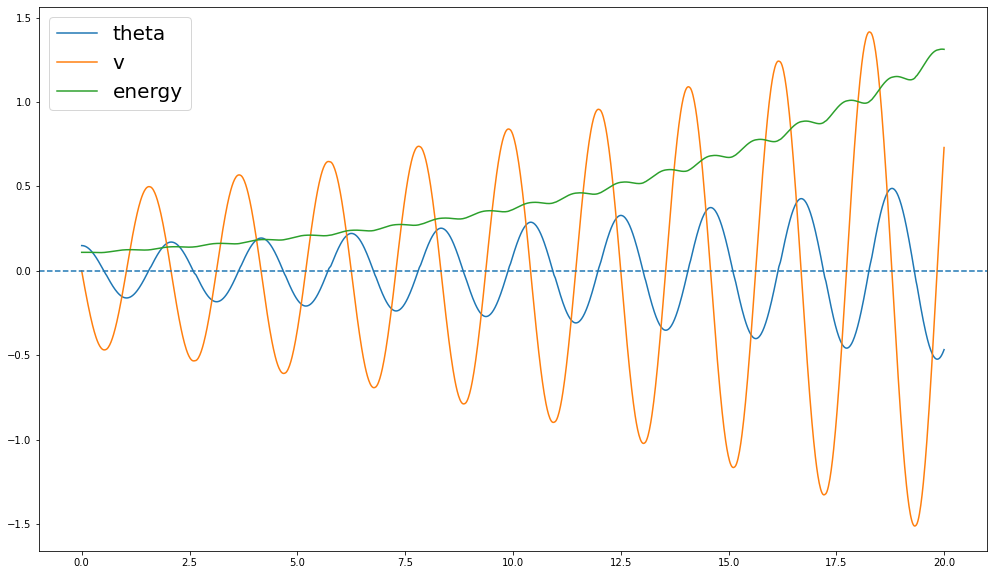

In [3]:
t,theta,v, e, acceleration = RKF(t1=20, theta_0=0.15, v_0=0, h0=0.0025, atol=0.0000000001, rtol=0.00000001)

plt.figure(figsize=[17,10])
plt.plot(t[0:-1],theta, label='theta')
plt.plot(t[0:-1],v, label='v')
# plt.plot(t[0:-1], acceleration, label='acceleration')
# plt.axhline(y=np.pi/2 , linestyle='--')
plt.axhline(y=0, linestyle='--')
plt.plot(t[0:-1], e, label='energy')
plt.legend(fontsize=20)
plt.show()